In [8]:
import numpy as np
import torch
import torch.nn as nn
import timm
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Class 2: Advanced 2D Visual Representation

本节课聚焦于三个里程碑式的视觉表征方法：**ViT**、**DINO**、**MAE**。
它们共同回答了一个核心问题：**如何让模型从图像中学到更强、更通用的特征？**

## Recap & Thinking

- **CNN的不足**：传统CNN通过堆叠卷积层建立感受野，全局建模能力弱，且归纳偏置（inductive bias）强，泛化能力受限。
- **LLM怎么做的**：Transformer 的 Self-Attention 机制让每个 token 直接关注所有其他 token，一步建立全局依赖。
- **为什么目前还没有统一的“视觉大模型”**: 大家对于ViT, DINO等视觉基础模型应该都有所耳闻，既然Transformer这套路线可以让LLM不断出圈，为什么基于Transformer的视觉模型还迟迟没有出现与之对等的现象级产品呢？

## LLM vs. CV：序列化图像的关键挑战

我们从LLM和CV任务的本质区别出发

<div align="center">

| | NLP (LLM) | CV (图像) |
|---|---|---|
| 基本单元 | Token（词/子词） | Pixel（像素） |
| 序列长度 | 200K | 单图大约 224×224 = 50,176（太长！）|
| Masked Attention | 有语序，可 causal mask（节省显存） | 无天然顺序，不可 mask |
| Scaling | 序列长度灵活 | 分辨率×2 → token 数×4，算力骤增 |
</div>

**解决方案（ViT的核心思路）**：将图像切分为固定大小的 **Patch**（图块），每个 Patch 作为一个 token，大幅压缩序列长度。

<div align="center">
  <img src="imgs/ViT.png" alt="ViT 模型结构" width="800">
</div>

---
## Part 1: Vision Transformer (ViT)

> 论文：*An Image is Worth 16x16 Words* (Dosovitskiy et al., 2020)

### 核心流程
1. 将图像切分为 `P×P` 的 Patch（如 16×16），共 `N = (H/P)×(W/P)` 个
2. 每个 Patch 展平后经线性投影映射为 D 维 embedding
3. 拼接一个可学习的 `[CLS]` token（用于分类）
4. 加上可学习的 **Position Embedding**
5. 送入标准 Transformer Encoder（多层 Multi-Head Self-Attention + FFN）
6. 取 `[CLS]` token 的输出接分类头

### 从公式到代码：图像怎样变成一串 token？

有了前面的直观图示，现在可以真正“落地”到代码上：一张 224×224 的彩色图像，会被我们切成一块块 16×16 的小方块，每一块都被看成一句话里的一个“词”。

`PatchEmbedding` 这段实现做的事情，其实就两件：
- 用一个步长等于核大小的卷积，把整张图按网格切开，每个格子压成一个向量；
- 把这些向量排成一行，得到长度为 N 的序列 `(B, N, D)`，后面就可以直接送进 Transformer。

In [5]:
# ── 1. Patch Embedding ──────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    """
    将图像切分成 Patch 并投影到 embed_dim 维空间。
    等价于一个 kernel_size=patch_size, stride=patch_size 的卷积。
    """
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # 2D Conv 实现 patch 切分 + 线性投影
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):          # x: (B, C, H, W)
        x = self.proj(x)           # -> (B, embed_dim, H/P, W/P)
        x = x.flatten(2)           # -> (B, embed_dim, N)
        x = x.transpose(1, 2)     # -> (B, N, embed_dim)
        return x

patch_embed = PatchEmbedding(img_size=224, patch_size=16, embed_dim=768)
dummy_img = torch.randn(2, 3, 224, 224)   # batch=2
out = patch_embed(dummy_img)
print(f"输入图像: {dummy_img.shape}")
print(f"Patch数量: {patch_embed.num_patches}  (14×14)")
print("压缩比例:", round(patch_embed.num_patches / (224 * 224) * 100, 2), "%")
print(f"Patch Embedding输出: {out.shape}  (B, N, D)")

输入图像: torch.Size([2, 3, 224, 224])
Patch数量: 196  (14×14)
压缩比例: 0.39 %
Patch Embedding输出: torch.Size([2, 196, 768])  (B, N, D)


### 把积木搭成一个完整的 ViT 小模型

当我们知道如何把图像切成 patch token 之后，接下来就是把这些“积木”拼起来：在 `MiniViT` 里，你可以看到课程开头提到的那条完整路线——patch 序列进来，前面加上一个代表整张图的 `[CLS]`，再配上位置编码，最后丢进一堆 Transformer Encoder 层里。

这一小节的代码可以当成“放大版简笔画”，和论文中的框图一一对应：每一行都能在图里找到自己的角色。

In [9]:
# ── 2. Mini-ViT ─────────────────────────────────
class MiniViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, num_classes=1000,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0):
        super().__init__()
        num_patches = (img_size // patch_size) ** 2

        # Patch Embedding
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)

        # 可学习的 [CLS] token 和 Position Embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim)) # （仅作演示，实际使用一般是RoPE等）

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # 分类头
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                              # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, D)
        x = torch.cat([cls, x], dim=1)                      # (B, N+1, D)
        x = x + self.pos_embed                              # 加位置编码
        x = self.transformer(x)                             # (B, N+1, D)
        x = self.norm(x[:, 0])                              # 取 [CLS] token
        return self.head(x)                                  # (B, num_classes)


mini_vit = MiniViT(img_size=224, patch_size=16, num_classes=10,
                   embed_dim=192, depth=4, num_heads=3)
dummy = torch.randn(1, 3, 224, 224)
logits = mini_vit(dummy)
print(f"模型参数量: {sum(p.numel() for p in mini_vit.parameters())/1e6:.1f}M")
print(f"输出 logits shape: {logits.shape}")

模型参数量: 2.0M
输出 logits shape: torch.Size([1, 10])


### 看一眼工业界用的 ViT 长什么样

前面我们自己手写了一个toy ViT，现在换一个视角：如果是在实际工程项目里，大家几乎不会从零开始搭网络，而是直接调用类似 `timm` 这样的模型库。

这段代码做的，就是把论文中的 ViT-B/16 以“预训练模型”的形式拿过来，顺手瞄一眼它的关键超参数，然后抽出一条 768 维的 `[CLS]` 特征。它和我们刚刚实现的 `MiniViT` 在结构上高度对应，只是规模更大、训练更充分，是后面 DINO、MAE 这些方法的共同“底座。

In [13]:
# ── 3. 加载预训练 ViT（使用 timm 库）──────────────────────────────────
# 加载在 ImageNet-21k 上预训练的 ViT-B/16
# pretrained=True 会自动下载权重（~330MB），首次运行需要网络
model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.eval()

# 查看模型结构关键参数
print(f"Patch Size:   {model.patch_embed.patch_size}")
print(f"Embed Dim:    {model.embed_dim}")
print(f"Depth:        {len(model.blocks)}")
print(f"Num Heads:    {model.blocks[0].attn.num_heads}")
print(f"参数总量:      {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

# 前向推理，提取 [CLS] 特征
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    features = model.forward_features(dummy)  # (1, 197, 768)
    cls_feat  = features[:, 0, :]             # [CLS] token -> (1, 768)
print(f"\n[CLS] 特征维度: {cls_feat.shape}")
print("=> 这个 768 维向量可直接用于下游任务（分类、检索等）")

Patch Size:   (16, 16)
Embed Dim:    768
Depth:        12
Num Heads:    12
参数总量:      86.6M

[CLS] 特征维度: torch.Size([1, 768])
=> 这个 768 维向量可直接用于下游任务（分类、检索等）


### Not Enough Yet
DPT，Register

这套框架至今都活跃在一线的视觉大模型里，例如：
> 2025 CVPR Best Paper：*VGGT: Visual Geometry Grounded Transformer* (Wang et al.)
<div align="center">
  <img src="imgs/VGGT.png" alt="VGGT 模型结构" width="800">
</div>

> 2025 ICCV：*SpatialTrackerV2: 3D Point Tracking Made Easy* (Xiao et al.)
<div align="center">
  <img src="imgs/spatialtracker.png" alt="VGGT 模型结构" width="800">
</div>



## LLM vs. CV **AGAIN**

看起来 ViT 的 Patchify 已经弥合了视觉与文字在“序列化”上的 gap，但为什么在 2023 年，LLM 已经可以长篇大论，而视频生成模型却还在“鬼影”中挣扎？

核心原因隐藏在 **Token 空间 (Token Space) 的本质性质** 中。

### 降维打击：为什么连续的 Token 空间是训练的“泥潭”？

- **LLM (离散语义锚点)**：语言的 Token 是离散的。即使你输入“apple”时手抖打成了“Apple”或是换了个同义词，模型预测的目标通常还是那个稳定的词表索引。这种**“分类式（Classification）”**的预测天然具有过滤噪音、锁定语义的能力。
- **CV (连续信号漂移)**：ViT 的 Token 是一个连续向量（通常 768 维）。当模型试图自回归预测下一个 Patch 时，它面对的是一个无线连续的特征空间。哪怕图像只是发生了一个微小的抖动，这个 Token 向量在空间中就会剧烈偏移。这种**“回归式（Regression）”**的任务让模型在 2023 年倍感吃力。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26571557..1.2693464].


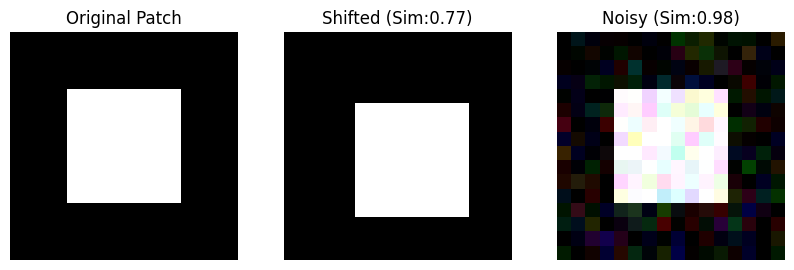

Token 空间余弦相似度 (Shifted): 0.7683
Token 空间余弦相似度 (Noisy):   0.9780

结论：在连续 Token 空间中，语义完全一致的 Patch，其向量表示却会剧烈漂移。
这种‘不稳定’的目标让早期的自回归回归架构极难收敛，稍微走错一步，预测就会滑向‘均值模糊’。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ── 1. 模拟一个简单的 PatchEmbedding 层 ───────────────────────────────
class MiniPatchEmbed(nn.Module):
    def __init__(self, patch_size=16, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)  # (B, N, D)

embed_layer = MiniPatchEmbed()

# ── 2. 创建三个“几乎相同”的 Patch 目标 ─────────────────────────────────
target_img = torch.zeros(1, 3, 16, 16)
target_img[:, :, 4:12, 4:12] = 1.0  # 原始：一个白色色块

shifted_img = torch.zeros(1, 3, 16, 16)
shifted_img[:, :, 5:13, 5:13] = 1.0 # 语义不变：位移了 1 像素

noisy_img = target_img + torch.randn_like(target_img) * 0.1 # 语义不变：加了点底噪

# ── 3. 观察它们在 Token 空间（Embedding）中的距离 ──────────────────────
with torch.no_grad():
    t_orig = embed_layer(target_img).squeeze(1)    # (1, 768)
    t_shift = embed_layer(shifted_img).squeeze(1)  # (1, 768)
    t_noise = embed_layer(noisy_img).squeeze(1)    # (1, 768)

cos_sim_shift = F.cosine_similarity(t_orig, t_shift).item()
cos_sim_noise = F.cosine_similarity(t_orig, t_noise).item()

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(target_img[0].permute(1,2,0)); axes[0].set_title("Original Patch")
axes[1].imshow(shifted_img[0].permute(1,2,0)); axes[1].set_title(f"Shifted (Sim:{cos_sim_shift:.2f})")
axes[2].imshow(noisy_img[0].permute(1,2,0)); axes[2].set_title(f"Noisy (Sim:{cos_sim_noise:.2f})")
for ax in axes: ax.axis('off')
plt.show()

print(f"Token 空间余弦相似度 (Shifted): {cos_sim_shift:.4f}")
print(f"Token 空间余弦相似度 (Noisy):   {cos_sim_noise:.4f}")
print("\n结论：在连续 Token 空间中，语义完全一致的 Patch，其向量表示却会剧烈漂移。")
print("这种‘不稳定’的目标让早期的自回归回归架构极难收敛，稍微走错一步，预测就会滑向‘均值模糊’。")

### 破局之道：如何让视觉也学会“说人话”？

正是因为连续 Token 的天然不稳定性，视觉大模型的演进出现了两条极具代表性的技术路径：

1.  **既然连续太难预测，那就强制离散化 (Discretization)**：
    - 代表作：**VQ-VAE / VQGAN**。给视觉安上“词表”（Codebook），不管向量怎么漂移，最后都强行“吸附”到最近的离散索引上。这让视觉模型获得了和 LLM 一样的纠错能力（如 VideoPoet, Llama-Gen）。

2.  **既然目标难以一步到位，那就学习去噪过程 (Diffusion Process)**：
    - 代表作：**Stable Diffusion / Sora**。不再强求一步预测出那个精确的连续向量，而是预测噪声。通过成百上千步的迭代，在数学上把“模糊”逐渐剔除。这是目前视觉生成的绝对主流。

3.  **终极理想：桥接离散与连续 (Hybrid)**：
    - 最新研究：**[TokenBridge (2025)](https://arxiv.org/pdf/2503.16430)**。它试图保留连续信号的丰富表达力，同时通过轻量级的离散化层获得 AR 模型的高效预测。这代表了“视觉大模型”向 LLM 终极大一统的最新尝试。

---
## Part 2: DINO — 自监督视觉 Transformer

> 论文：*Emerging Properties in Self-Supervised Vision Transformers* (Caron et al., 2021)

### 核心思想：知识蒸馏 × 自监督

DINO 最惊人的发现：**无需任何标注**，仅靠自监督训练，ViT 的注意力图就能自动分割出语义目标。

**Teacher-Student 自蒸馏框架**：

```
同一张图像
  ├─ 多个局部裁剪（Local Crops） → Student 网络 → 输出分布 p_s
  └─ 全局裁剪（Global Crops）  → Teacher 网络 → 输出分布 p_t
                                                       ↑
                                         EMA 更新（无梯度）
```

**损失函数**（交叉熵，让 Student 预测 Teacher 的输出）：

$$\mathcal{L} = -\sum_{x \in \{\text{global}\}} \sum_{x' \neq x} p_t(x) \log p_s(x')$$

| 关键设计 | 作用 |
|---|---|
| Centering（中心化） | 防止模式坍塌（所有输出趋于一致）|
| EMA Teacher | 提供稳定的监督信号，不直接反传梯度 |
| Multi-crop | 让模型学习局部到全局的语义一致性 |

### 让模型自己去看世界：从损失函数到注意力图

光有损失函数还不够直观，DINO 真正让人震撼的地方在于：哪怕从来没人告诉它“这是猫”“那是背景”，它学出来的注意力图，居然会自动把前景和背景分开。

下面两段代码分别做两件事：
- 用官方预训练的 DINO 模型，把一张普通的猫图像变成一组 `[CLS]` 和 patch 特征；
- 把最后一层里的自注意力拿出来，在原图上铺开，让我们直接“看见”模型眼中的重要区域。

可以先想一想：如果完全没有标签，模型关注的地方会不会乱飘？再看可视化结果，顺势引出“自监督也能长出语义分割”的这个现象。

In [ ]:
import torch
import torch.nn.functional as F

# ── DINO Loss 核心实现 ─────────────────────────────────────────────
class DINOLoss(torch.nn.Module):
    def __init__(self, out_dim, teacher_temp=0.04, student_temp=0.1,
                 center_momentum=0.9):
        super().__init__()
        self.teacher_temp = teacher_temp
        self.student_temp = student_temp
        self.center_momentum = center_momentum
        # center 用于防止坍塌
        self.register_buffer('center', torch.zeros(1, out_dim))

    def forward(self, student_out, teacher_out):
        """
        student_out: list of (B, D) tensors（所有 crop 的输出）
        teacher_out: list of (B, D) tensors（仅全局 crop 的输出）
        """
        # Teacher: 减去 center（防坍塌），然后 softmax
        teacher_out_centered = [(t - self.center) / self.teacher_temp
                                for t in teacher_out]
        teacher_probs = [F.softmax(t, dim=-1).detach()  # 无梯度！
                         for t in teacher_out_centered]

        # Student: 直接 log_softmax
        student_log_probs = [F.log_softmax(s / self.student_temp, dim=-1)
                             for s in student_out]

        # 交叉熵：Student 的所有 crop 预测 Teacher 的所有全局 crop
        total_loss = 0
        n_loss_terms = 0
        for t_prob in teacher_probs:
            for s_log_prob in student_log_probs:
                loss = -(t_prob * s_log_prob).sum(dim=-1).mean()
                total_loss += loss
                n_loss_terms += 1

        # 更新 center（EMA）
        with torch.no_grad():
            batch_center = torch.cat(teacher_out).mean(0, keepdim=True)
            self.center = (self.center * self.center_momentum +
                           batch_center * (1 - self.center_momentum))

        return total_loss / n_loss_terms

# 演示
loss_fn = DINOLoss(out_dim=65536)
# 模拟 2 个全局 crop 的 Teacher 输出，4 个 Student 输出
B, D = 4, 65536
teacher_outputs = [torch.randn(B, D), torch.randn(B, D)]
student_outputs = [torch.randn(B, D) for _ in range(4)]
loss = loss_fn(student_outputs, teacher_outputs)
print(f"DINO Loss: {loss.item():.4f}")

### MAE：把大部分图像盖住，再逼你还原出来

如果说 DINO 的故事是“看不同视角要给出一致的判断”，那 MAE 讲的是另一种训练方式：我们干脆把图像的大部分都遮住，只留下很少一部分，让模型去把被盖住的地方补全。

想象你只看到拼图中 1/4 的小块，却要猜出整张图长什么样——自然就不能只死盯局部纹理，而是要尽量抓住全局结构。接下来这段随机遮掩的代码，就是在做这样一个游戏的抽象：在 196 个 patch 中，只挑出 49 个，让其余 147 个统统“失踪”，再看模型能不能把它们合理地补回来。

In [ ]:
# ── 使用 Facebook 官方预训练 DINO 权重提取特征 ──────────────────────
# 权重会从 GitHub Releases 自动下载（~330MB）
import torch
import torchvision.transforms as T
from PIL import Image
import requests
from io import BytesIO

# 加载预训练 DINO ViT-S/16（Facebook 官方）
dino_model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16',
                             pretrained=True)
dino_model.eval()
print(f"DINO ViT-S/16 参数量: {sum(p.numel() for p in dino_model.parameters())/1e6:.1f}M")

# 图像预处理
transform = T.Compose([
    T.Resize(256), T.CenterCrop(224), T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 下载一张示例图片
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg"
img = Image.open(BytesIO(requests.get(url).content)).convert('RGB')
x = transform(img).unsqueeze(0)   # (1, 3, 224, 224)

with torch.no_grad():
    # 提取所有 token 的特征（含 [CLS]）
    feats = dino_model.get_intermediate_layers(x, n=1)[0]  # (1, 197, 384)
    cls_feat = feats[:, 0, :]   # [CLS] token
    patch_feats = feats[:, 1:, :]  # 196 个 patch tokens

print(f"[CLS] 特征: {cls_feat.shape}")
print(f"Patch 特征: {patch_feats.shape}  (14×14 个 patch，每个 384 维）")

### 从预训练特征回到下游任务：特征空间里的“邻居”是谁

不管是有监督的 ViT，还是自监督的 DINO、MAE，到最后都会给我们一个高维的特征向量。那怎么判断这些特征“好不好用”呢？

一种朴素但很有直觉的方法，就是做近邻检索：拿一张查询图片在特征空间里向外“打招呼”，看看最先回应它的，是不是语义上真正相似的那些图片。下面的 kNN 小例子，就是把这种检查方式写成了可以随手调用的函数，后面你可以把随机特征换成真实模型的输出，亲自体验一下不同预训练方式带来的差异。

In [ ]:
# ── DINO 注意力图可视化（核心亮点）──────────────────────────────────
# DINO 无监督学到的注意力 ≈ 语义分割图！


def visualize_dino_attention(model, img_tensor, patch_size=16):
    """可视化最后一层 attention 的 [CLS] → patch 注意力权重"""
    w_feat = img_tensor.shape[-2] // patch_size
    h_feat = img_tensor.shape[-1] // patch_size

    with torch.no_grad():
        # 获取最后一个 block 的 attention
        attentions = model.get_last_selfattention(img_tensor)  # (1, heads, N+1, N+1)

    # 取 [CLS] token 对所有 patch 的注意力
    nh = attentions.shape[1]  # 头数
    attn = attentions[0, :, 0, 1:].reshape(nh, w_feat, h_feat)  # (heads, 14, 14)

    # 上采样到原始图像尺寸
    attn_up = torch.nn.functional.interpolate(
        attn.unsqueeze(0), scale_factor=patch_size, mode='bilinear')[0]

    fig, axes = plt.subplots(1, nh + 1, figsize=(3 * (nh + 1), 3))
    axes[0].imshow(img)
    axes[0].set_title('Original', fontsize=10)
    axes[0].axis('off')
    for i in range(nh):
        axes[i + 1].imshow(attn_up[i].numpy(), cmap='inferno')
        axes[i + 1].set_title(f'Head {i}', fontsize=10)
        axes[i + 1].axis('off')
    plt.suptitle('DINO Self-Attention (CLS → Patches)', fontsize=12)
    plt.tight_layout()
    plt.show()

visualize_dino_attention(dino_model, x)
# 观察：不同的注意力头自动关注图像的不同语义区域（前景/背景）

---
## Part 3: MAE — Masked Autoencoders

> 论文：*Masked Autoencoders Are Scalable Vision Learners* (He et al., 2021)

### 核心思想：遮掩重建（类比 BERT for Vision）

**设计哲学**：随机遮掩图像的大部分 patch（75%！），让模型重建被遮掩的像素值。

```
原始图像 (196 patches)
     │  随机遮掩 75%（147 patches）
     ▼
可见 patches（49个） → Encoder（完整 ViT）→ 可见 patch 特征
     │  + mask tokens（可学习 embedding）
     ▼
所有 patches → Decoder（轻量 Transformer）→ 重建所有 patch 像素
     │
     ▼
Loss = MSE( 重建像素, 原始像素 )  仅在 masked patch 上计算
```

| 设计亮点 | 说明 |
|---|---|
| **高遮掩率 75%** | 比 NLP（15%）高得多，强迫模型理解全局语义而非局部纹理 |
| **非对称 Encoder-Decoder** | Encoder 只处理可见 patch（省计算），Decoder 轻量 |
| **像素级重建** | 预测归一化后的原始像素值，而非离散 token |

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ── MAE 随机遮掩策略可视化 ─────────────────────────────────────────
def random_masking(x, mask_ratio=0.75):
    """
    x: (B, N, D)  N 个 patch tokens
    返回: x_masked（可见 patch），mask（1=masked），ids_restore（还原顺序）
    """
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))  # 保留数量

    # 用随机噪声排序来实现随机采样
    noise = torch.rand(B, N)              # (B, N)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    # 保留前 len_keep 个（随机）
    ids_keep = ids_shuffle[:, :len_keep]
    x_masked = torch.gather(x, 1,
        ids_keep.unsqueeze(-1).expand(-1, -1, D))   # (B, len_keep, D)

    # 生成 mask（1 = 被遮掩）
    mask = torch.ones(B, N)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, 1, ids_restore)        # 还原到原始顺序

    return x_masked, mask, ids_restore


# 演示：对一张图像可视化遮掩效果
def show_masking_demo(mask_ratio=0.75, patch_size=16, img_size=224):
    n = img_size // patch_size  # 14
    N = n * n                   # 196
    dummy_patches = torch.zeros(1, N, 1)  # 仅用于演示 mask
    _, mask, _ = random_masking(dummy_patches, mask_ratio)

    mask_grid = mask[0].reshape(n, n).numpy()
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(np.ones((n, n, 3)))  # 白色图像
    axes[0].set_title('原始图像（示意）', fontsize=12)
    axes[0].axis('off')

    masked_img = np.ones((n, n, 3))
    masked_img[mask_grid == 1] = [0.2, 0.2, 0.2]  # 被遮掩 patch 显示为深灰
    axes[1].imshow(masked_img)
    axes[1].set_title(f'遮掩后（{mask_ratio*100:.0f}% masked，灰色部分）', fontsize=12)
    axes[1].axis('off')
    plt.suptitle('MAE 随机遮掩策略', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"可见 patch 数: {int(N*(1-mask_ratio))} / {N}")

show_masking_demo(mask_ratio=0.75)

In [ ]:
# ── 使用预训练 MAE 提取特征（timm）─────────────────────────────────
# 权重为 MAE 预训练的 ViT-Base（在 ImageNet-1K 自监督预训练）
# 下载方式：
#   wget https://dl.fbaipublicfiles.com/mae/pretrain/mae_pretrain_vit_base.pth
# 或者使用 timm 中已经集成的 MAE 权重：
import timm
import torch

# timm 中 mae_pretrain_vit_base 暂未直接集成，可用 vit_base_patch16_224.mae 加载
# 以下演示加载方式（需提前下载权重到本地）
mae_model = timm.create_model('vit_base_patch16_224', pretrained=False)

# 若已下载权重文件，取消注释后运行：
# ckpt = torch.load('mae_pretrain_vit_base.pth', map_location='cpu')
# # MAE 权重中 encoder 部分的 key 需要做前缀处理
# state_dict = {k.replace('encoder.', ''): v
#               for k, v in ckpt['model'].items() if 'decoder' not in k}
# mae_model.load_state_dict(state_dict, strict=False)
# print("MAE 权重加载成功")

mae_model.eval()
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    feats = mae_model.forward_features(dummy)  # (1, 197, 768)
    cls_feat = feats[:, 0, :]
print(f"MAE 预训练特征维度: {cls_feat.shape}")
print("=> MAE 的 [CLS] 特征可用于 fine-tuning 下游任务（分类、检测、分割）")

---
## 总结与对比

### 三种方法横向对比

| | ViT | DINO | MAE |
|---|---|---|---|
| **训练范式** | 有监督（ImageNet 标签）| 自监督（无标签）| 自监督（无标签）|
| **预训练任务** | 图像分类 | Teacher-Student 自蒸馏 | Masked Patch 重建 |
| **监督信号** | 人工标注标签 | 自身的 Teacher 输出 | 原始像素值 |
| **特征性质** | 语义强，需标签 | 语义强 + 显式分割性 | 像素细节强 + 语义 |
| **Patch 利用率** | 100%（全部送入）| 100%（Multi-crop）| 25%（Encoder 只看可见）|
| **核心贡献** | 证明 Transformer 可用于 CV | 无监督获得语义分割能力 | 极高遮掩率的重建学习 |
| **局限** | 需大量标注数据 | 训练复杂度高 | 重建任务≠语义理解 |

### 关键洞见

1. **ViT** 打破了 CNN 的归纳偏置，证明 Transformer 在视觉中同样有效，但需要大规模标注数据。
2. **DINO** 揭示了 ViT 内部的自监督语义结构——注意力图天然对应语义区域，为无标注的预训练指引了方向。
3. **MAE** 借鉴 BERT 的遮掩预训练思路，通过极高遮掩率（75%）迫使 Encoder 建立高层语义理解，并以非对称设计大幅提升训练效率。

**发展脉络**：
```
ViT (2020) ──→ DINO (2021) ──→ MAE (2021) ──→ DINOv2 (2023) ──→ ...
 有监督迁移      自监督语义         自监督重建        更强更通用
```

In [ ]:
# ── 特征质量对比：近邻检索（kNN）──────────────────────────────────
# 一个简单但直观的方式：看特征空间中语义近邻是否合理
import torch
import torch.nn.functional as F

def knn_retrieval(query_feat, gallery_feats, gallery_labels, k=5):
    """用余弦相似度找 k 个最近邻"""
    q = F.normalize(query_feat, dim=-1)    # (1, D)
    g = F.normalize(gallery_feats, dim=-1) # (N, D)
    sims = (q @ g.T).squeeze(0)            # (N,)
    topk_idx = sims.topk(k).indices
    return [(gallery_labels[i], sims[i].item()) for i in topk_idx]

# 模拟：用随机特征演示接口（实际使用时替换为真实模型输出）
torch.manual_seed(42)
D = 768
query = torch.randn(1, D)
gallery = torch.randn(100, D)
labels = [f'class_{i%10}' for i in range(100)]

results = knn_retrieval(query, gallery, labels, k=5)
print("kNN 检索结果（Top-5）:")
for label, sim in results:
    print(f"  {label}  相似度={sim:.4f}")
print("\n=> 在真实预训练特征上，语义相似的图像应出现在 Top-K 中")